In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

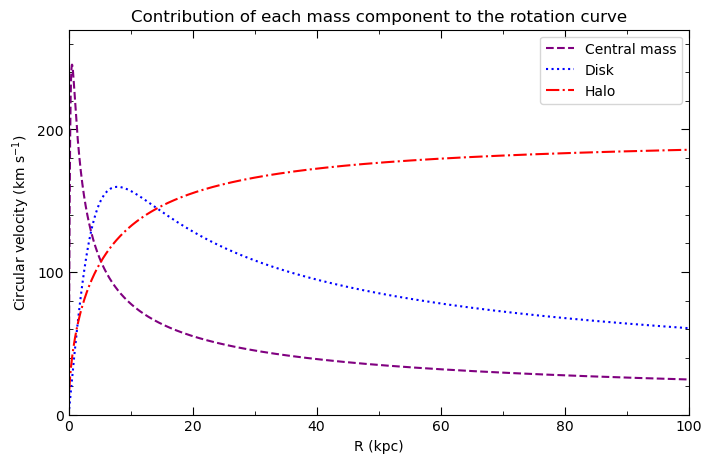

In [2]:
x = np.linspace(0.001,100,10000) # kpc units
y = np.linspace(0.001,100,10000)
z = np.zeros(10000)
#z = np.linspace(0.001,100,10000)

R = np.sqrt(x**2 + y**2 + z**2) # kpc units

# Central mass
M1 = 606.
b1 = 0.3873

dphi_x1 =  M1*x/(x**2 + y**2 + z**2 + b1**2)**(3/2)
dphi_y1 =  M1*y/(x**2 + y**2 + z**2 + b1**2)**(3/2)
dphi_z1 =  M1*z/(x**2 + y**2 + z**2 + b1**2)**(3/2) 

vel_c1 = np.sqrt(100*(dphi_x1*x + dphi_y1*y + dphi_z1*z)) # km/s

# Disk component
M2 = 3690.
a2 = 5.3178
b2 = 0.25

dphi_x2 = M2*x / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2)**(3/2)
dphi_y2 = M2*y / (x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2)**(3/2)
#dphi_z2 = M2*z*(a2*(1/np.sqrt(z** + b2**2)) + 1) / (np.sqrt(x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2))**3
dphi_z2 = M2*z*(a2 + np.sqrt(z**2 + b2**2))/(np.sqrt(z**2 + b2**2)*(np.sqrt(x**2 + y**2 + (a2 + np.sqrt(z**2 + b2**2))**2))**3)

vel_c2 = np.sqrt(100*(dphi_x2*x + dphi_y2*y + dphi_z2*z)) # km/s

# Halo
M3 = 4615.
a3 = 12.

a = -(1.02*M3*(x/R))*((R/a3)**2.02)
b = R*(1+(R/a3)**1.02)

c = M3 * x * ((R/a3)**(1.02)) / (a3 * R**2)
d = 1 + (R/a3)**(1.02)

dphi_x3 = c / d
dphi_y3 = dphi_x3
dphi_z3 = dphi_x3

vel_c3 = np.sqrt(100*(dphi_x3*x + dphi_y3*y + dphi_z3*z))

dphi_x = dphi_x1 + dphi_x2 + dphi_x3
dphi_y = dphi_y1 + dphi_y2 + dphi_y3
dphi_z = dphi_z1 + dphi_z2 + dphi_z3

v = np.sqrt(dphi_x*x + dphi_y*y + dphi_z*z)*10
#v = vel_c1 + vel_c2 + vel_c3

plt.figure(figsize=(8, 5))
plt.plot(R, vel_c1, color = "purple", label = "Central mass", linestyle = "dashed")
plt.plot(R, vel_c2, color = "blue", label = "Disk", linestyle = "dotted")
plt.plot(R, vel_c3, color = "red", label = "Halo", linestyle = "dashdot")

plt.tick_params(axis = "both", which = "both", direction = "in", top = True, right = True)

plt.gca().xaxis.set_major_locator(MultipleLocator(20)) # Números cada 20
plt.gca().xaxis.set_minor_locator(MultipleLocator(10))  # Rayitas cada 10
plt.tick_params(axis='x', which='minor', size = 3, color='black')
plt.tick_params(axis='x', which='major', size = 6, color='black')

plt.gca().yaxis.set_major_locator(MultipleLocator(100)) # Números cada 100
plt.gca().yaxis.set_minor_locator(MultipleLocator(20))  # Rayitas cada 20
plt.tick_params(axis='y', which='minor', size = 3, color='black')
plt.tick_params(axis='y', which='major', size = 6, color='black')

plt.title("Contribution of each mass component to the rotation curve")
plt.xlabel("R (kpc)")
plt.ylabel("Circular velocity (km s$^{-1}$)")
plt.xlim(0,100)
plt.ylim(0,270)
plt.legend()
plt.savefig("./graphs/rotation_curve_components(AllenSantillan).png")
plt.show()

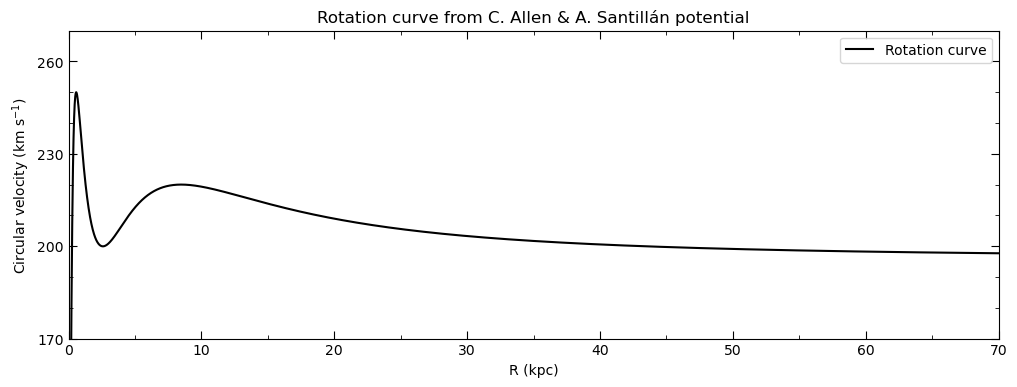

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(R, v, color = "k", label = "Rotation curve")
plt.xlabel("R (kpc)")
plt.ylabel("Circular velocity (km s$^{-1}$)")
plt.title("Rotation curve from C. Allen & A. Santillán potential")
plt.xlim(0,70)
plt.ylim(170,270)

plt.tick_params(axis = "both", which = "both", direction = "in", top = True, right = True)
plt.yticks([170, 200, 230, 260]) 

plt.gca().xaxis.set_major_locator(MultipleLocator(10)) # Números cada 10
plt.gca().xaxis.set_minor_locator(MultipleLocator(5))  # Rayitas cada 5
plt.tick_params(axis='x', which='minor', size = 3, color='black')
plt.tick_params(axis='x', which='major', size = 6, color='black')

#plt.gca().yaxis.set_major_locator(MultipleLocator(30)) # Números cada 30
plt.gca().yaxis.set_minor_locator(MultipleLocator(10))  # Rayitas cada 10
plt.tick_params(axis='y', which='minor', size = 3, color='black')
plt.tick_params(axis='y', which='major', size = 6, color='black')

plt.legend()
plt.savefig("./graphs/rotation_curve(AllenSantillan).png")
plt.show()